# Data Dictionary

In [1]:
# Basic liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn liberaries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('bank.csv')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
data.shape

(11162, 17)

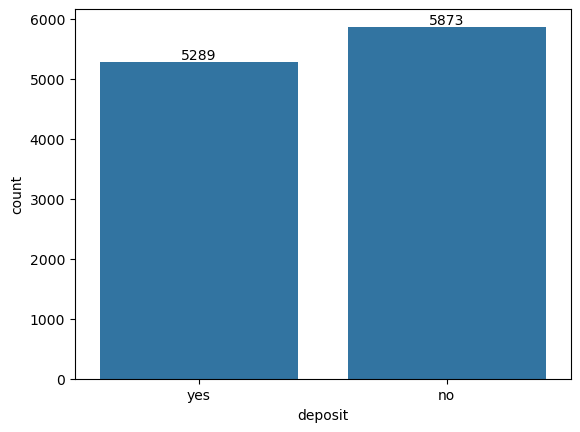

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64

In [4]:
# Analysing the target column

ax = sns.countplot(x='deposit', data=data)
ax.bar_label(ax.containers[0])
plt.show()

# Proportion check
# to see the distribution of the data wheather it is normally distributed or not

round(data['deposit'].value_counts(normalize=True)*100,2)

In [5]:
# checking the null values

data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [7]:
# number of unique columns in categorical columns

for cols in data.columns:
    if data[cols].dtype =='O':
        print(cols, ':',data[cols].nunique())

job : 12
marital : 3
education : 4
default : 2
housing : 2
loan : 2
contact : 3
month : 12
poutcome : 4
deposit : 2


# Preparing the data for ML models

In [8]:
# dependency split

x = data.drop('deposit', axis=1)

# independent split

y = data[['deposit']]
print(x.shape, y.shape, sep='\n')

(11162, 16)
(11162, 1)


In [9]:
# train test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(x_train.shape,x_test.shape,y_train.shape, y_test.shape, sep='\n')

(7813, 16)
(3349, 16)
(7813, 1)
(3349, 1)


# Encoding

In [10]:
# List of categorical coluumns

cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype =='O']

# Label encoder

encoders = {}

#Apply label encoder for train data

for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

# Apply label encoder for test data

for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

In [11]:
encoders = {}
for col in cat_cols:
    encoders[col] = LabelEncoder()
print(encoders)


{'job': LabelEncoder(), 'marital': LabelEncoder(), 'education': LabelEncoder(), 'default': LabelEncoder(), 'housing': LabelEncoder(), 'loan': LabelEncoder(), 'contact': LabelEncoder(), 'month': LabelEncoder(), 'poutcome': LabelEncoder()}


In [12]:
# data sample after encoding
x_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
7968,57,9,1,1,0,950,1,0,0,9,5,1272,1,-1,0,3
1456,34,9,2,2,0,925,1,0,0,13,0,709,1,-1,0,3
361,41,1,2,1,0,75,1,0,2,1,5,479,9,-1,0,3
812,46,9,2,2,0,4414,0,0,0,18,1,504,7,-1,0,3
1092,28,11,2,1,0,4465,0,0,0,28,4,769,1,-1,0,3


In [13]:
# Building a simple decision tree with random parameters values

model = DecisionTreeClassifier(max_depth=7,random_state=42)
model.fit(x_train, y_train)
train_score = model.score(x_train,y_train)
print('Training Score:', round(train_score*100,2),'%')

Training Score: 83.69 %


In [14]:
# test prediction

y_pred = model.predict(x_test)

# testing accuracy

test_score = accuracy_score(y_test, y_pred)
print('Test Score:', round(test_score*100,2),'%')
print('Precision Score:',round(precision_score(y_test, y_pred, pos_label='yes')*100,2),'%')
print('Recall_score:',round(recall_score(y_test, y_pred, pos_label='yes')*100,2),'%')

Test Score: 81.55 %
Precision Score: 83.85 %
Recall_score: 76.23 %


              precision    recall  f1-score   support

          no       0.80      0.86      0.83      1742
         yes       0.84      0.76      0.80      1607

    accuracy                           0.82      3349
   macro avg       0.82      0.81      0.81      3349
weighted avg       0.82      0.82      0.81      3349



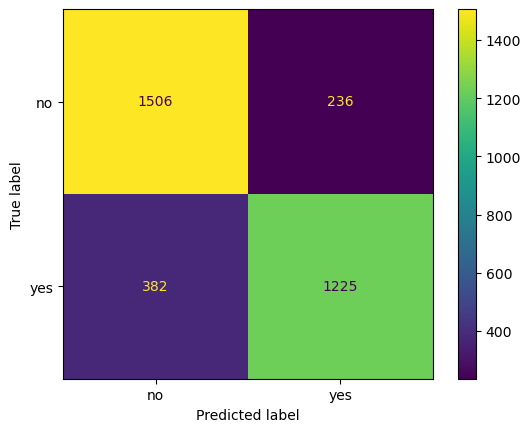

In [15]:
# Confusion matrix

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print(classification_report(y_test, y_pred))